In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)
np.set_printoptions(precision=3, suppress=True)

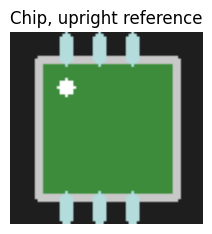

In [2]:
def make_chip(size=70):
    img = np.full((size, size, 3), (30, 30, 30), dtype=np.uint8)
    cv2.rectangle(img, (10, 10), (size - 10, size - 10), (60, 140, 60), -1)
    cv2.rectangle(img, (10, 10), (size - 10, size - 10), (200, 200, 200), 2)
    pin_len = 8
    for x in range(20, size - 15, 12):
        cv2.line(img, (x, 10), (x, 10 - pin_len), (220, 220, 180), 3)
        cv2.line(img, (x, size - 10), (x, size - 10 + pin_len), (220, 220, 180), 3)
    cv2.circle(img, (20, 20), 3, (255, 255, 255), -1)
    return img

chip = make_chip()
cv2.imwrite('data_chip.png', chip)
plt.figure(figsize=(2.5, 2.5))
plt.imshow(cv2.cvtColor(chip, cv2.COLOR_BGR2RGB))
plt.title('Chip, upright reference')
plt.axis('off')
plt.savefig('output/00_chip_reference.png', bbox_inches='tight', dpi=150)
plt.show()

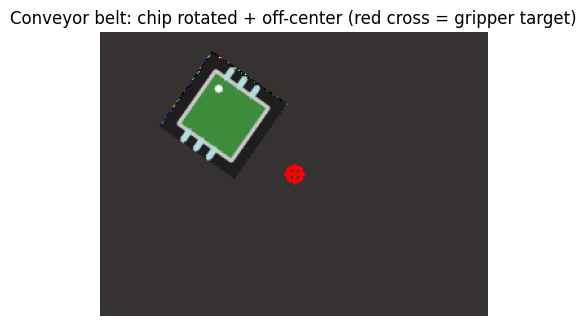

In [3]:
belt_w, belt_h = 300, 220
gripper_target = np.array([belt_w / 2, belt_h / 2])
current_chip_center = np.array([95.0, 65.0])
current_angle_deg = 35.0

ch, cw = chip.shape[:2]
chip_center_local = np.array([cw / 2, ch / 2])

theta_place = np.deg2rad(current_angle_deg)
R_place = np.array([[np.cos(theta_place), -np.sin(theta_place)],
                     [np.sin(theta_place),  np.cos(theta_place)]])
t_place = current_chip_center - R_place @ chip_center_local
M_place = np.hstack([R_place, t_place.reshape(2, 1)])

def make_belt_bg(w, h, target):
    bg = np.full((h, w, 3), (50, 50, 55), dtype=np.uint8)
    cv2.circle(bg, tuple(target.astype(int)), 6, (0, 0, 255), 2)
    cv2.drawMarker(bg, tuple(target.astype(int)), (0, 0, 255), cv2.MARKER_CROSS, 14, 2)
    return bg

def composite(bg, layer, mask):
    out = bg.copy()
    out[mask > 0] = layer[mask > 0]
    return out

chip_mask_src = np.full((ch, cw), 255, dtype=np.uint8)
placed_chip = cv2.warpAffine(chip, M_place, (belt_w, belt_h), borderMode=cv2.BORDER_TRANSPARENT)
placed_mask = cv2.warpAffine(chip_mask_src, M_place, (belt_w, belt_h))

belt_bg = make_belt_bg(belt_w, belt_h, gripper_target)
belt = composite(belt_bg, placed_chip, placed_mask)

plt.figure(figsize=(5, 4))
plt.imshow(cv2.cvtColor(belt, cv2.COLOR_BGR2RGB))
plt.title('Conveyor belt: chip rotated + off-center (red cross = gripper target)')
plt.axis('off')
plt.savefig('output/01_belt_scene.png', bbox_inches='tight', dpi=150)
plt.show()

Rotation matrix R =
 [[ 0.819  0.574  0.   ]
 [-0.574  0.819  0.   ]
 [ 0.     0.     1.   ]]
Combined 3x3 rigid matrix M = T_to_target @ R @ T_to_origin =
 [[  0.819   0.574  34.898]
 [ -0.574   0.819 111.245]
 [  0.      0.      1.   ]]


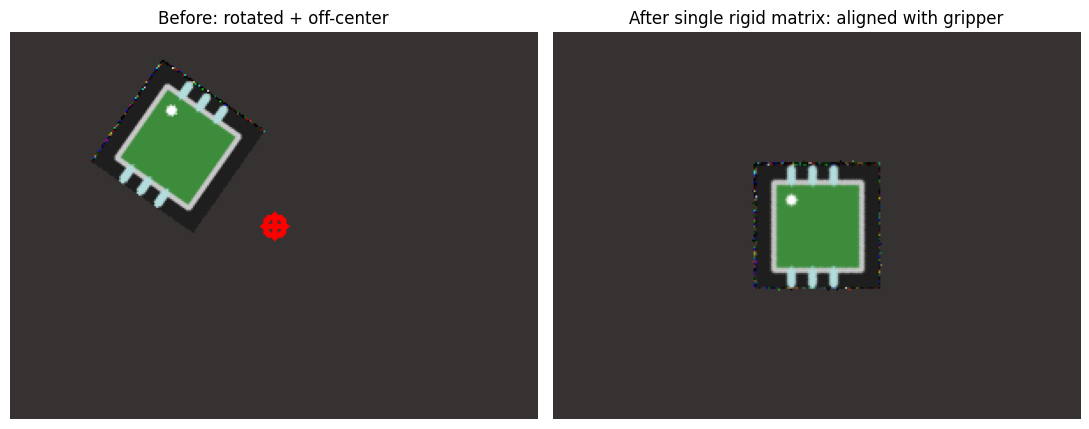

In [4]:
theta_correct = np.deg2rad(-current_angle_deg)
R = np.array([
    [np.cos(theta_correct), -np.sin(theta_correct), 0],
    [np.sin(theta_correct),  np.cos(theta_correct), 0],
    [0, 0, 1]
])
print('Rotation matrix R =\n', R)

T_to_origin = np.array([
    [1, 0, -current_chip_center[0]],
    [0, 1, -current_chip_center[1]],
    [0, 0, 1]
])

T_to_target = np.array([
    [1, 0, gripper_target[0]],
    [0, 1, gripper_target[1]],
    [0, 0, 1]
])

M = T_to_target @ R @ T_to_origin
print('Combined 3x3 rigid matrix M = T_to_target @ R @ T_to_origin =\n', M)

aligned_chip = cv2.warpAffine(placed_chip, M[:2, :], (belt_w, belt_h), borderMode=cv2.BORDER_TRANSPARENT)
aligned_mask = cv2.warpAffine(placed_mask, M[:2, :], (belt_w, belt_h))
aligned_belt = composite(belt_bg, aligned_chip, aligned_mask)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(cv2.cvtColor(belt, cv2.COLOR_BGR2RGB))
axes[0].set_title('Before: rotated + off-center')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(aligned_belt, cv2.COLOR_BGR2RGB))
axes[1].set_title('After single rigid matrix: aligned with gripper')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/02_aligned.png', bbox_inches='tight', dpi=150)
plt.show()